In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ecommerce_sales_dataset.csv")

print(df.head())
print(df.shape)

     OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003  2023-10-15     C33540    Chair         1     273.19   
4  ORD200004  2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREE

In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB
None


In [19]:
print(df.isnull().sum())

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [20]:
df["CouponCode"] = df["CouponCode"].fillna("NoCoupon")

print(df.isnull().sum())

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [21]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["TotalPrice"] < lower) |
    (df["TotalPrice"] > upper)
]

print("Number of Outliers:", len(outliers))
print(outliers[["TotalPrice"]].head())

Number of Outliers: 8
     TotalPrice
107     3353.75
326     3352.40
328     3370.20
469     3384.90
632     3390.80


In [22]:
import numpy as np

df["TotalPrice"] = np.clip(
    df["TotalPrice"],
    lower,
    upper
)

print("Outliers handled successfully")

Outliers handled successfully


In [23]:
df["Date"] = pd.to_datetime(df["Date"])

df["OrderMonth"] = df["Date"].dt.month

df["AvgItemCost"] = (
    df["TotalPrice"] / df["Quantity"]
)

df["CouponUsed"] = (
    df["CouponCode"] != "NoCoupon"
).astype(int)

print(df.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  OrderMonth  AvgItemCost  CouponUsed  
0     SAVE10      Instagram     2853.10           1       570

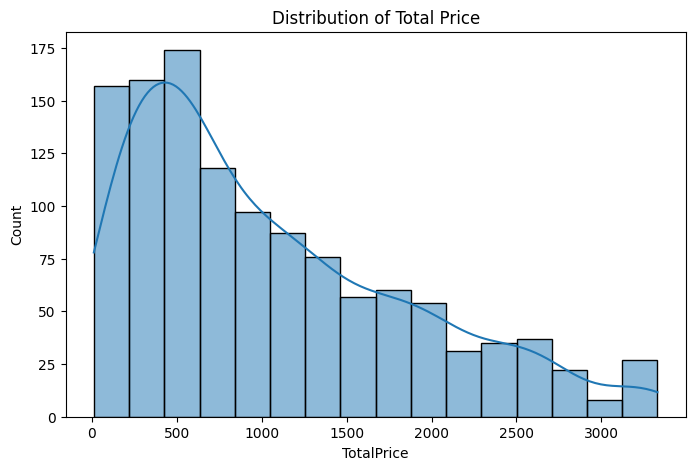

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df["TotalPrice"], kde=True)
plt.title("Distribution of Total Price")
plt.show()

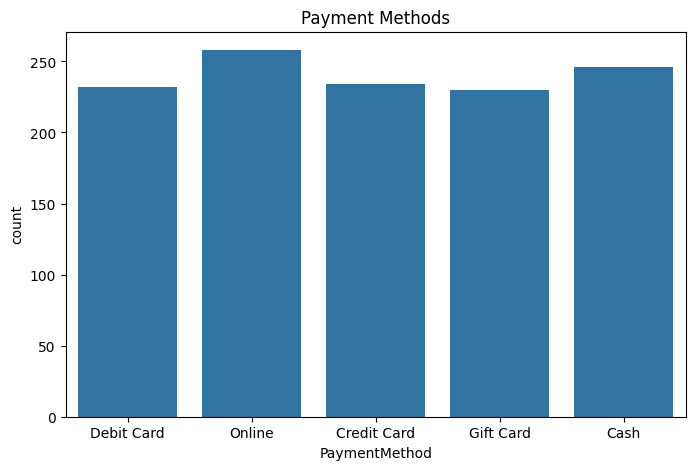

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x="PaymentMethod", data=df)
plt.title("Payment Methods")
plt.show()

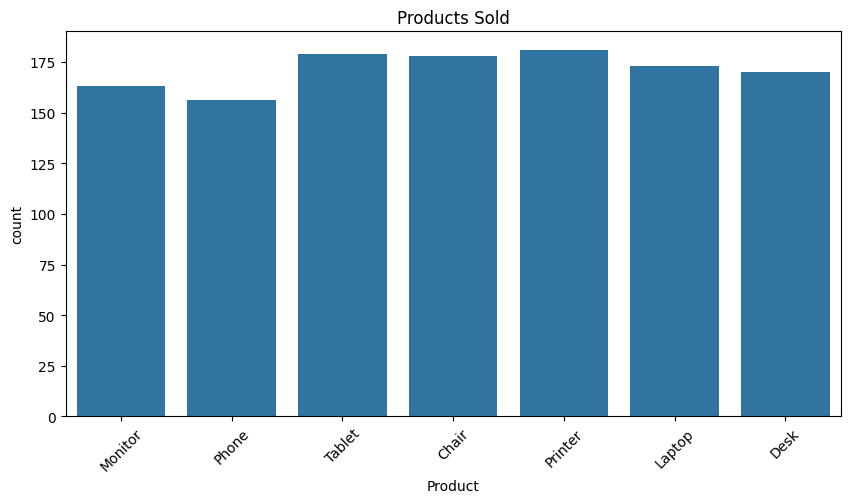

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(x="Product", data=df)
plt.title("Products Sold")
plt.xticks(rotation=45)
plt.show()

In [27]:
df.to_csv(
    "Cleaned_Ecommerce_Dataset.csv",
    index=False
)

print("Dataset saved successfully")

Dataset saved successfully
